# ROCprofv3 Tutorial for AMD GPU Performance Analysis

This tutorial demonstrates how to use AMD's latest performance profiling toolset `rocprofv3` on servers with AMD GPUs. We will create a naive **matrix multiplication** kernel, generate profiling data, and package it for analysis with **ROCprof Compute Viewer** on your local machine.

---

## AMD GPU Multi-Level Cache Hierarchy

Understanding the cache hierarchy is crucial for optimizing matrix multiplication on AMD GPUs:

**AMD CDNA Architecture Cache Hierarchy:**

1. **L1 Data Cache (64KB per CU)**: Fastest cache, stores frequently accessed data
2. **L1 Code Cache (32KB per CU)**: Stores instruction code
3. **L2 Cache (Shared across all CUs in a Compute Tile)**: Larger shared cache for data reuse
4. **Global HBM Memory**: High Bandwidth Memory, slowest but largest capacity

**Key Optimization Strategies for MatMul:**
- Utilize L2 cache for better data reuse across warps
- Use shared memory (via `__shared__`) to reduce global memory accesses
- Optimize memory access patterns for coalescing and cache efficiency

---

## 1. Environment Setup

First, let's verify that the GPU is functioning correctly and load the necessary ROCm modules.

In [ ]:
# Check if GPU is working
!rocm-smi --showproductname

---

## 2. Prepare Example Program (HIP MatMul)

We will write a naive **matrix multiplication kernel** as the analysis target. This is ideal for demonstrating **AMD GPU cache hierarchy** optimizations. **Note:** To view source code in the Viewer, compile with debugging information (`-g`).

In [1]:
%%writefile matmul.hip
#include <hip/hip_runtime.h>
#include <iostream>

__global__ void kernel1_naive(const float *A, const float *B, float *C, int M, int K, int N, float alpha, float beta)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < M && col < N)
    {
        float acc_c = 0.0f;
        for (int k = 0; k < K; ++k)
        {
            acc_c += A[row * K + k] * B[k * N + col];
        }
        C[row * N + col] = alpha * acc_c + beta * C[row * N + col];
    }
}

int main() {
    int M = 4096, K = 4096, N = 4096;
    float alpha = 1.0f, beta = 0.0f;

    size_t size_A = M * K * sizeof(float);
    size_t size_B = K * N * sizeof(float);
    size_t size_C = M * N * sizeof(float);

    float *h_A = new float[M * K]();
    float *h_B = new float[K * N]();
    float *h_C = new float[M * N]();

    for (int i = 0; i < M * K; i++) h_A[i] = 1.0f;
    for (int i = 0; i < K * N; i++) h_B[i] = 2.0f;

    float *d_A, *d_B, *d_C;
    hipMalloc(&d_A, size_A);
    hipMalloc(&d_B, size_B);
    hipMalloc(&d_C, size_C);

    hipMemcpy(d_A, h_A, size_A, hipMemcpyHostToDevice);
    hipMemcpy(d_B, h_B, size_B, hipMemcpyHostToDevice);
    hipMemcpy(d_C, h_C, size_C, hipMemcpyHostToDevice);

    dim3 blockDim(16, 16);
    dim3 gridDim((N + 15) / 16, (M + 15) / 16);

    hipLaunchKernelGGL(kernel1_naive, gridDim, blockDim, 0, 0, d_A, d_B, d_C, M, K, N, alpha, beta);

    hipMemcpy(h_C, d_C, size_C, hipMemcpyDeviceToHost);
    std::cout << "Matrix multiplication completed!" << std::endl;

    hipFree(d_A); hipFree(d_B); hipFree(d_C);
    delete[] h_A; delete[] h_B; delete[] h_C;
    return 0;
}

Writing matmul.hip


---

## 3. Compile the Program

We need to use `hipcc` for compilation. The key is to use `-g` and `-O2` flags so that `ROCprof` can associate hardware counters with your source code lines.

In [2]:
!hipcc -g -O2 matmul.hip -o matmul

matmul.hip:35:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   35 |     hipMalloc(&d_A, size_A);
      |     ^~~~~~~~~~~~~~~~~~~~~~~
matmul.hip:36:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   36 |     hipMalloc(&d_B, size_B);
      |     ^~~~~~~~~~~~~~~~~~~~~~~
matmul.hip:37:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   37 |     hipMalloc(&d_C, size_C);
      |     ^~~~~~~~~~~~~~~~~~~~~~~
matmul.hip:39:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   39 |     hipMemcpy(d_A, h_A, size_A, hipMemcpyHostToDevice);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
matmul.hip:40:5: warning: ignoring return value of type 'hipError_t' declared with 'nodiscard' attribute [-Wunused-value]
   40 |     hipMemcpy(d_B, h_B, size_B, hipM

---

## 4. Generate Profiling Data Using ROCprofv3

We will run `rocprofv3` with the following options:

- `--att`: Enable trace decoder
- `--att-activity 16`: Set sampling frequency (between 1-32), crucial for generating summaries and associating source code
- `-d`: Specify output directory

Att files here are **VERY** large, it may take 60+s to finish writing disk.

In [5]:
# Generate trace decoder profiling data
!rocprofv3 --att --att-activity 16 -d tracedecoder_matMul -- ./matmul

[rocprofv3] Fatal error: rocprof-trace-decoder library path not found in ['', '/opt/rocm-7.2.0/lib']


---

## 5. Alternative Output: CSV Counter Collection

In addition to ATT traces, `rocprofv3` supports CSV output format for counter collection. This is useful for post-processing and analysis with custom scripts.

### CSV Output Format Columns:
```
Correlation_Id, Dispatch_Id, Agent_Id, Queue_Id, Process_Id, Thread_Id,
Grid_Size, Kernel_Id, Kernel_Name, Workgroup_Size, LDS_Block_Size,
Scratch_Size, VGPR_Count, SGPR_Count, Counter_Name, Counter_Value,
Start_Timestamp, End_Timestamp
```

### Example: Generate CSV Counter Data

In [ ]:
# Generate CSV counter collection data
# --pmc specifies performance counters to collect
# -f csv specifies CSV output format
!rocprofv3 --pmc SQ_WAVES,SQ_WAVES_RESTORED -f csv -d csv_output -- ./matmul

### Converting CSV to rocprofv3 Format

If you need compatibility with old rocprofv1 tools, use the conversion script:

```bash
python3 /opt/rocm/core-7.11/share/rocprofiler-sdk/convert-counters-collection-format.py \
    -i csv_output/ -o converted_output.csv
```

---

## 6. Perfetto Trace Output

`rocprofv3` supports generating traces in **Perfetto** format, which can be visualized in [Perfetto UI](https://ui.perfetto.dev/).

### Perfetto-Specific Options:
```
--perfetto-backend {inprocess,system}  # Data collection backend
                                      # 'system' requires traced/perfetto daemons

--perfetto-buffer-size KB             # Buffer size (default: 1 GB)

--perfetto-buffer-fill-policy {discard,ring_buffer}
                                      # Policy when buffer is full

--perfetto-shmem-size-hint KB         # Shared memory hint (default: 64 KB)
```

### Example: Generate Perfetto Trace

In [ ]:
# Generate Perfetto trace (pftrace format)
!rocprofv3 --sys-trace -f pftrace --perfetto-backend inprocess -d perfetto_output -- ./matmul

---

## 7. Package the Profiling Data (Don't run!)

The generated `tracedecoder_matMul` directory contains multiple files. For ease of download, we will package it as a `.tgz` archive.

### You should not download the file here since it is too large for classroom download.
### You can download the example on bb.

In [ ]:
import os
from IPython.display import FileLink

# Package directory
!tar -czvf tracedecoder_matMul.tgz tracedecoder_matMul

# Generate download link
FileLink('tracedecoder_matMul.tgz')

---

## 8. Next Steps: Analyze Locally on Windows




## Following instructions for you to take home.

Follow these steps to view the data on your local computer:

1. **Download** the `tracedecoder_matMul.tgz` file generated above.

2. **Install Viewer**: Download the Windows version of `Rocprof-Compute-Viewer-win64.exe` from [AMD GPUOpen](https://gpuopen.com/rdts-windows/) and install it.

3. **Import Data**:
   - Unzip the `.tgz` file locally.
   - Open **ROCprof Compute Viewer**.
   - Click **Import** in the upper left corner and select the `ui_output_agent_xxxx_dispatch_x` folder from the unzipped directory.

4. **Explore Analysis**:
   - In **Instructions View**, see which line of code (e.g., matmul loop) takes the most time.
   - In **Summary View**, observe if there are memory bandwidth bottlenecks (Memory Bandwidth Bound).
   - Check **Wave States Timeline** to analyze for stalls or wait states.

Following is two images of Rocprof-Compute-Viewer.

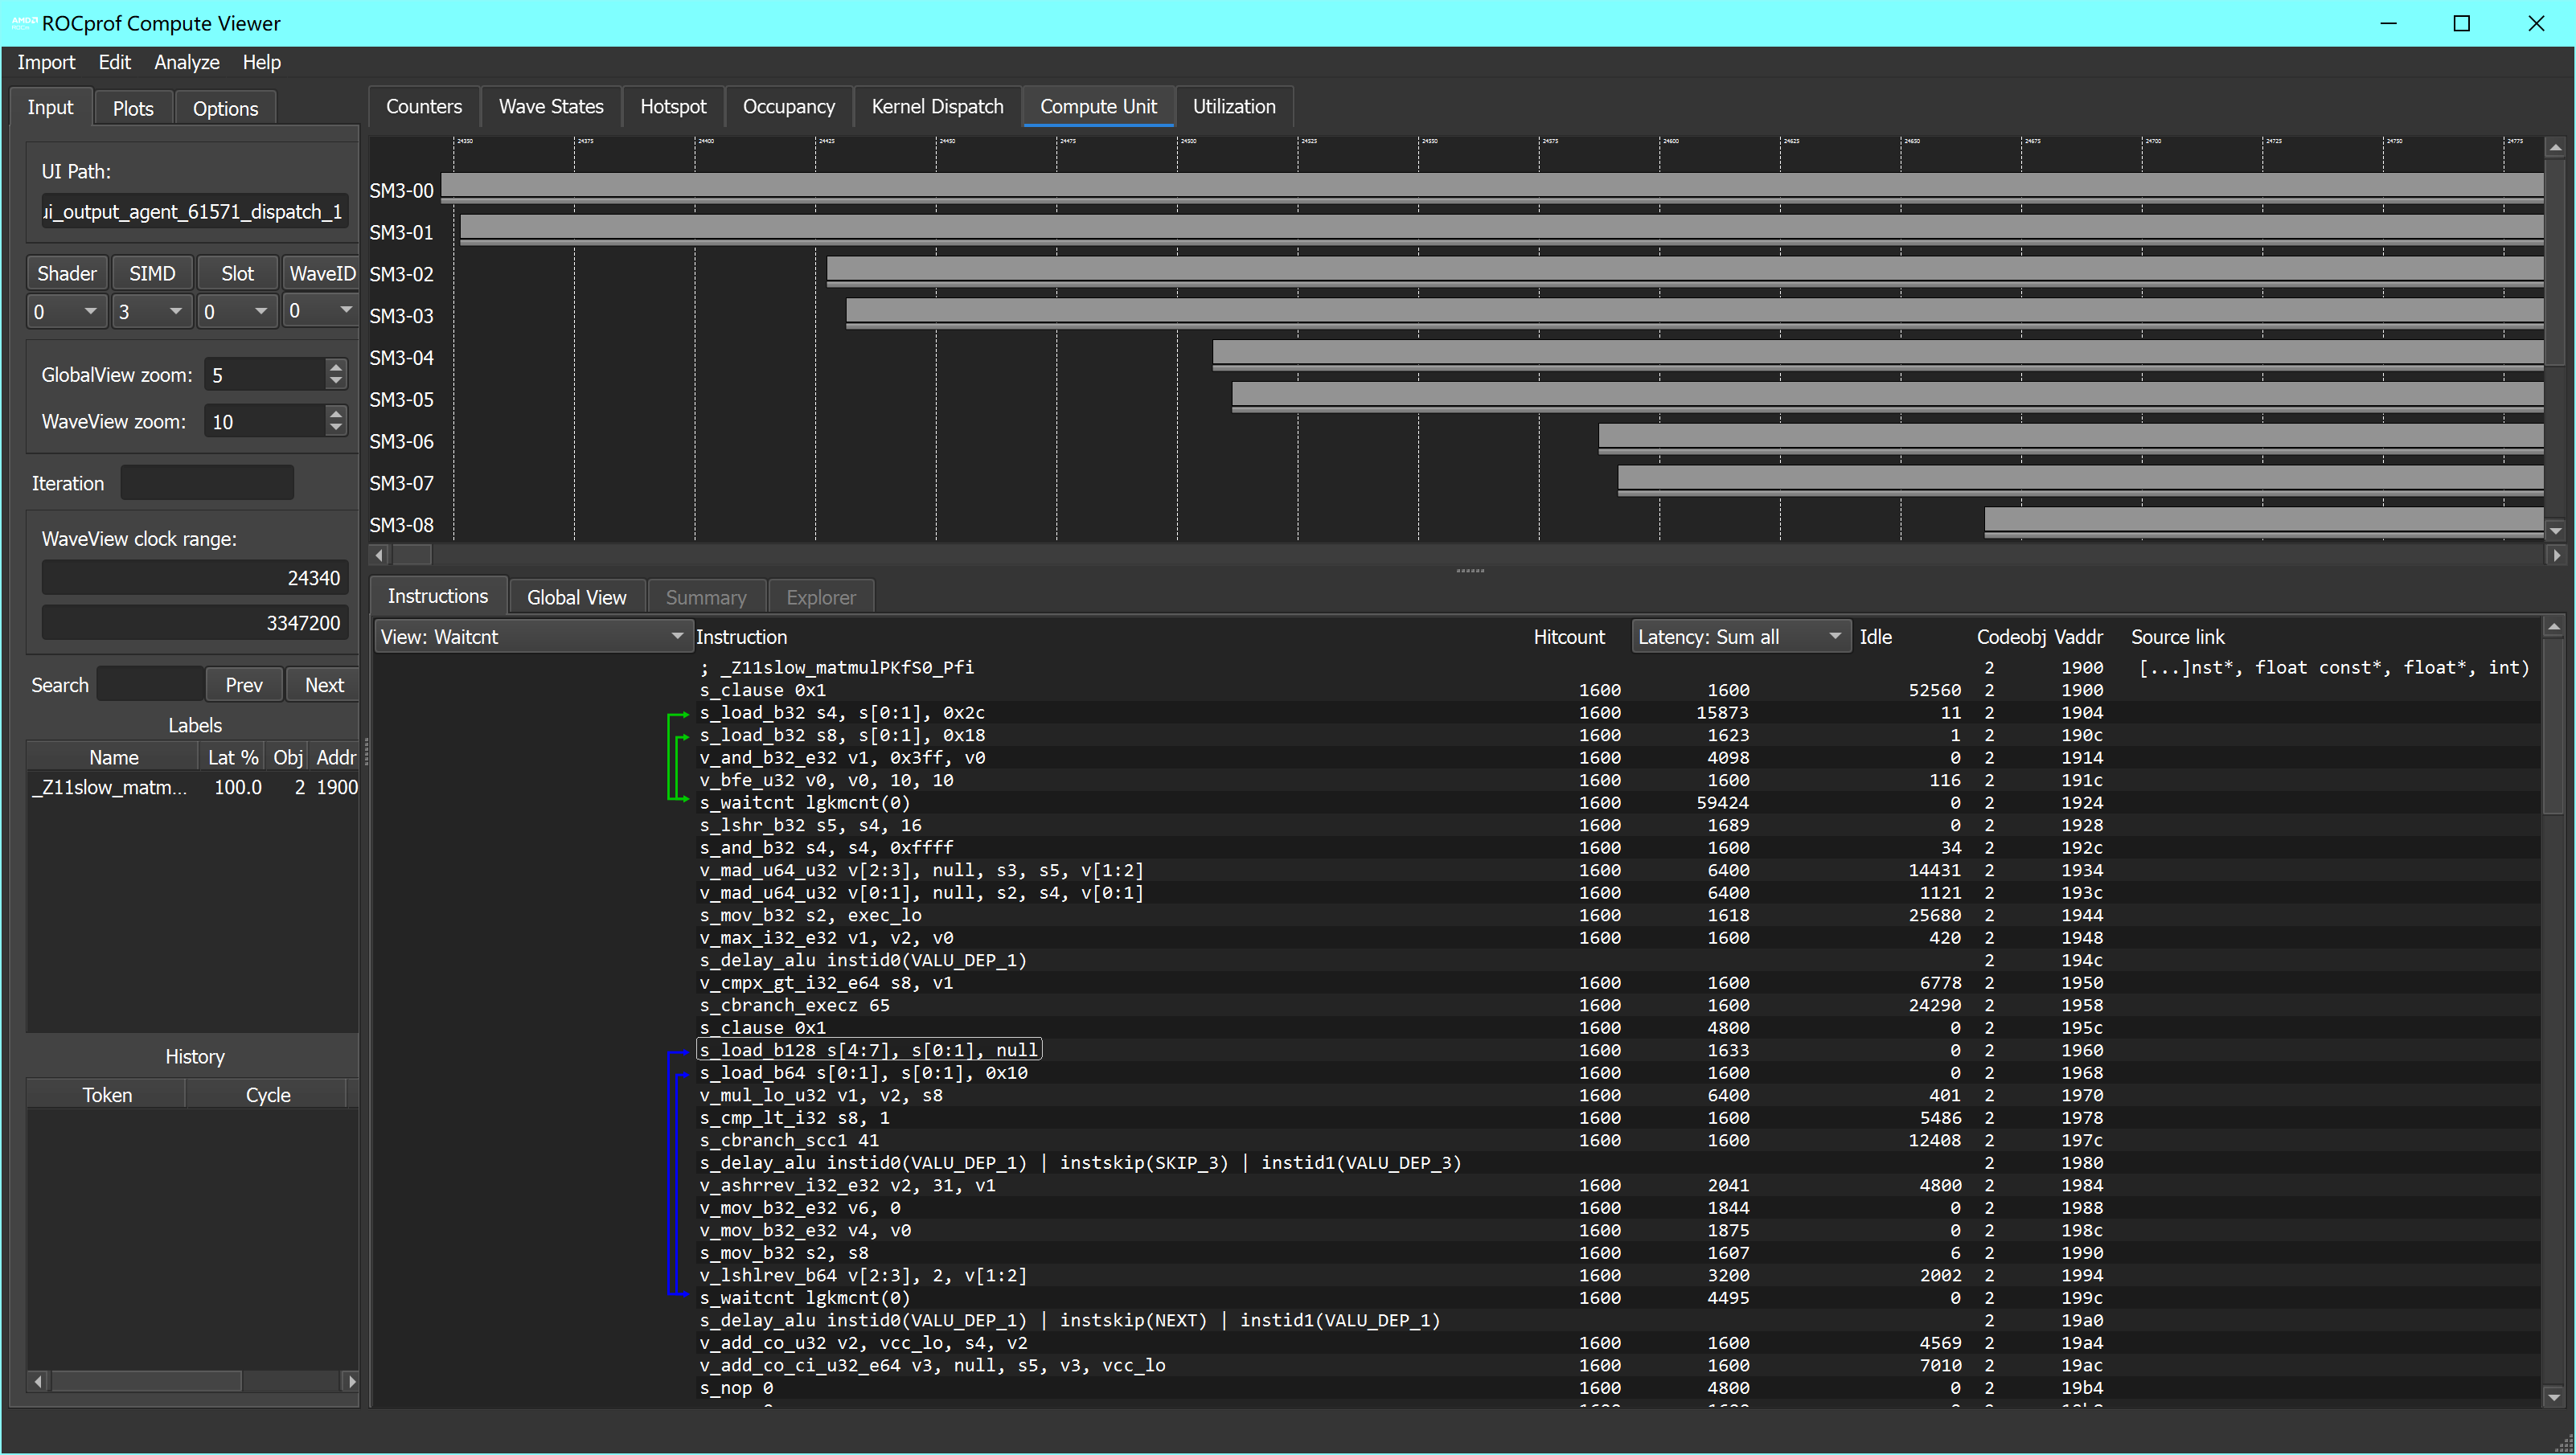
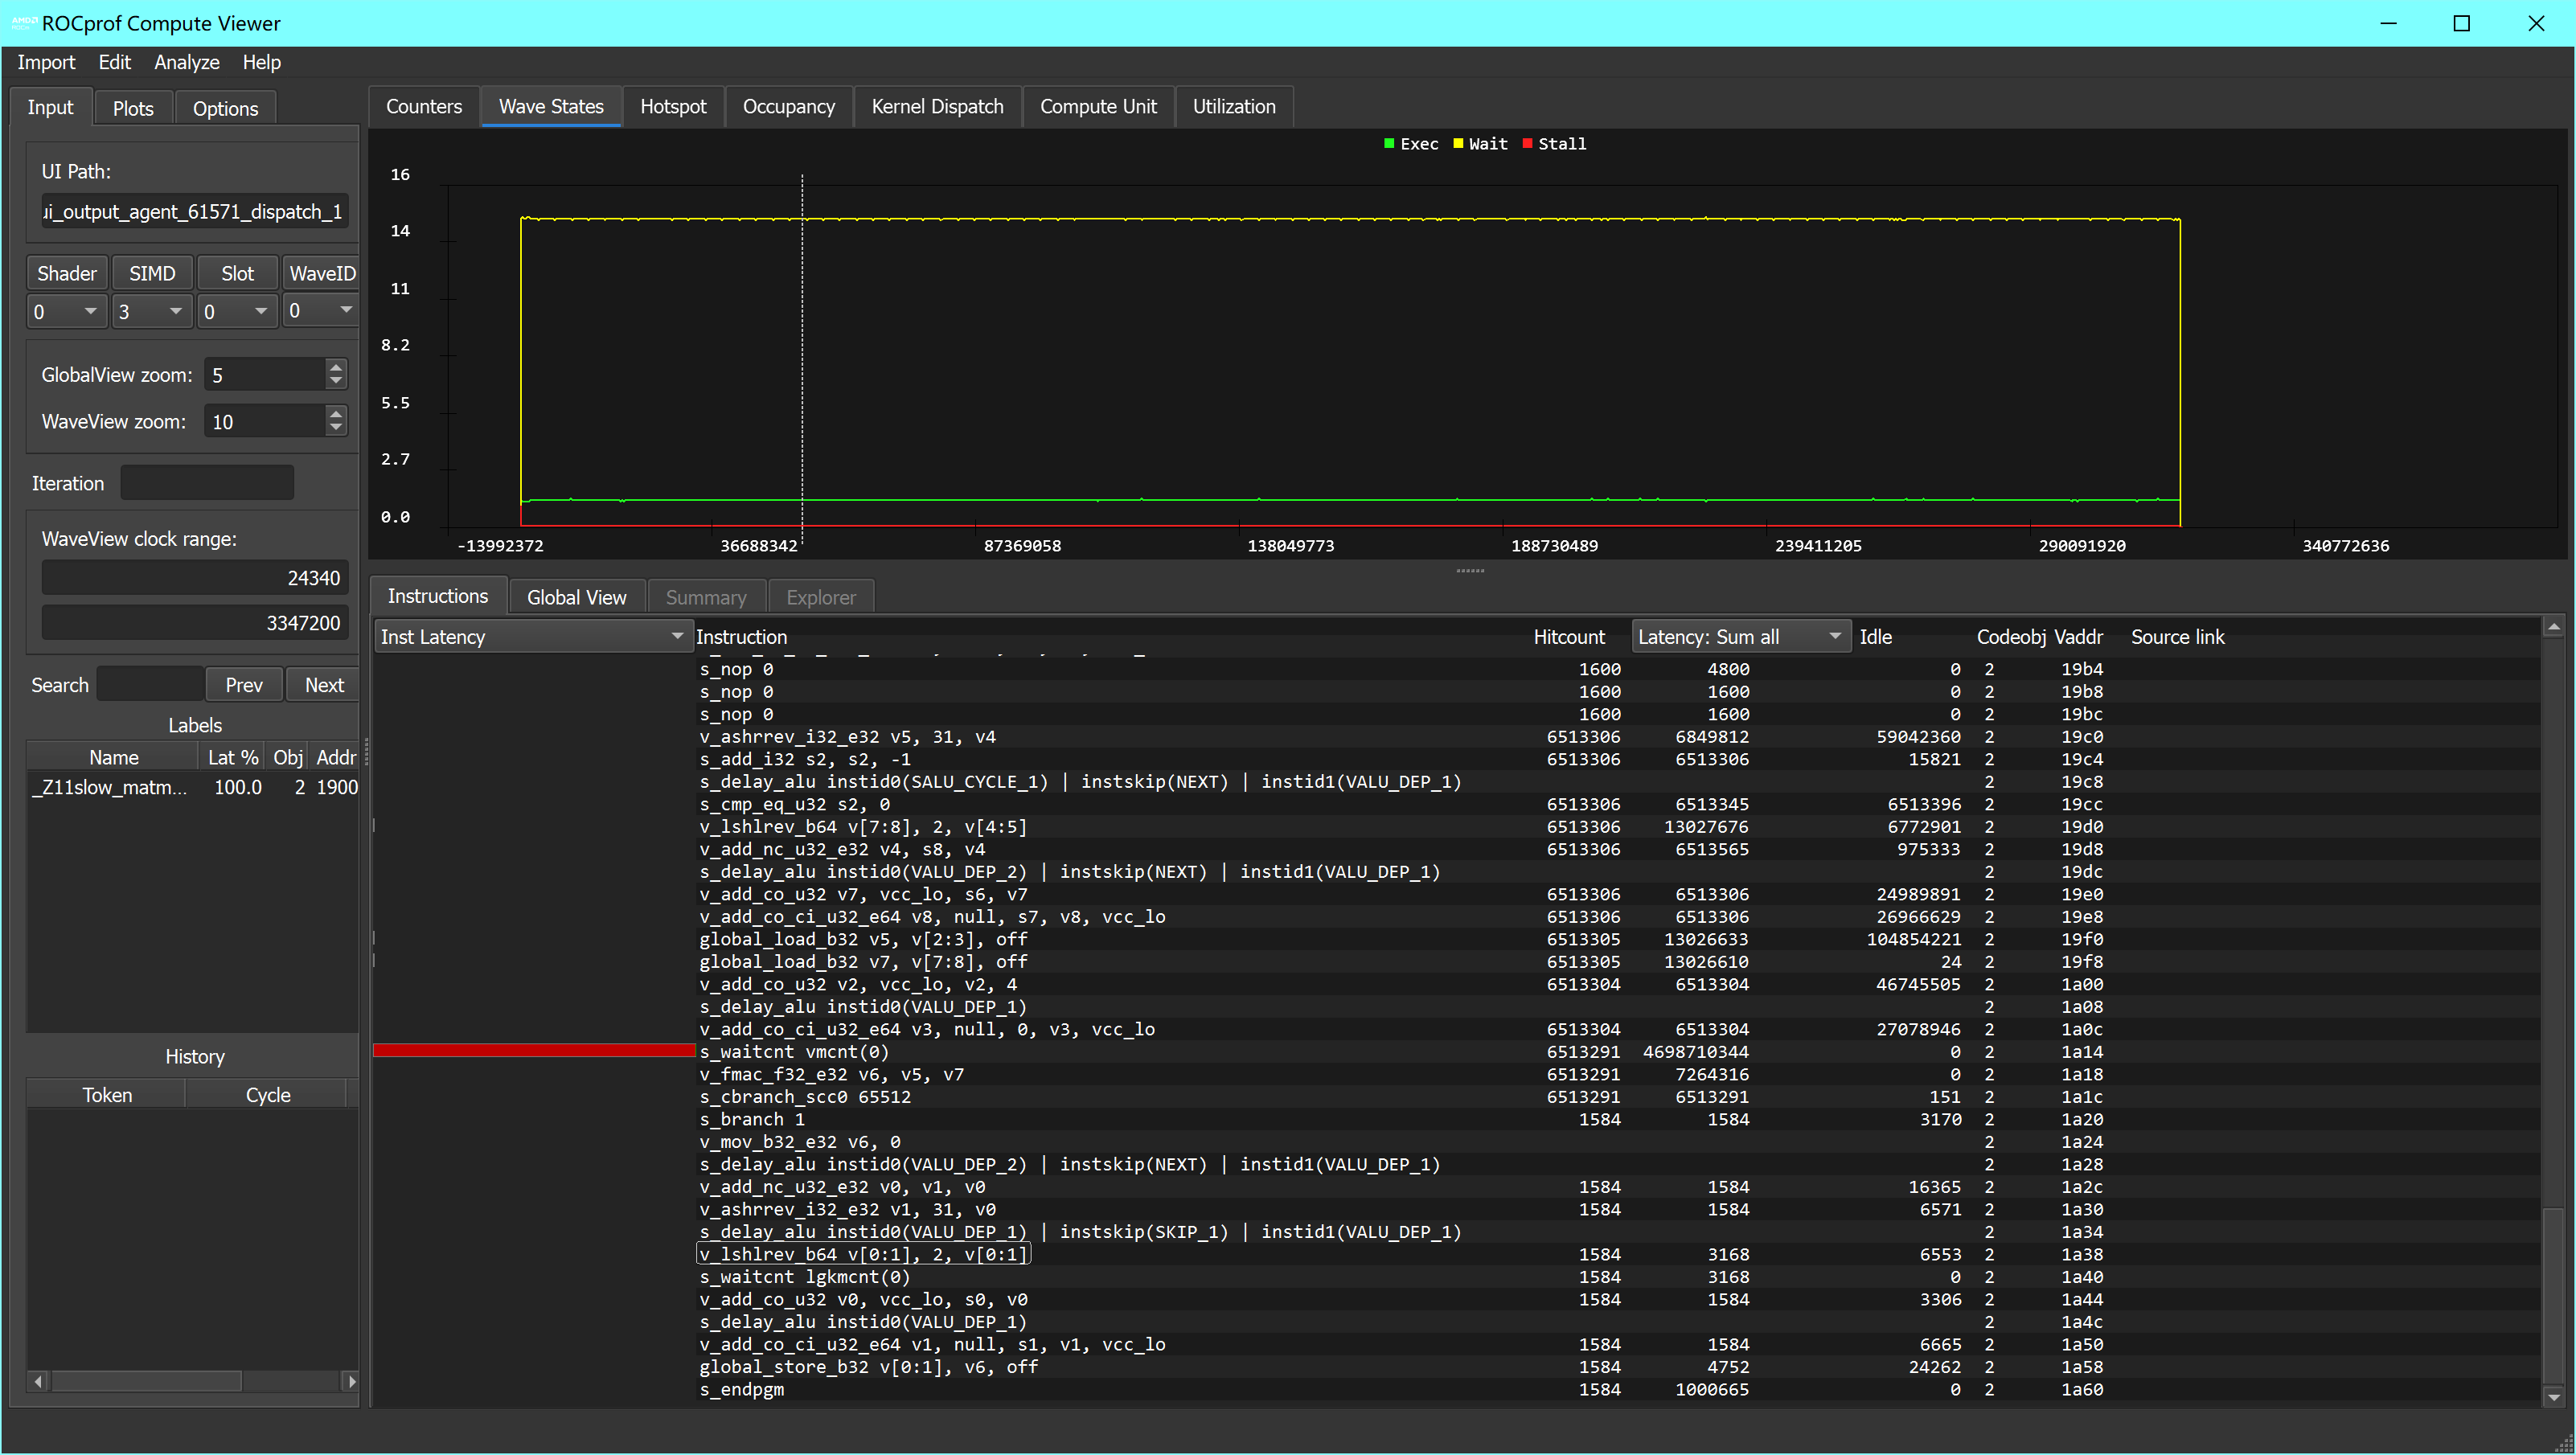

# 9. Little Optimized Example Program (HIP MatMul)

### Advantages of Transposition

By transposing the matrix, we effectively transform the **columns** of the original matrix $B$ into the **rows** of the new matrix $B_T$. This leads to two critical performance gains:

#### 1. **Optimized Memory Coalescing**

In `kernel1_coalesced`, when threads within a single **Warp** (or Wavefront) execute a load instruction, they access **contiguous** memory addresses.

* **Without Transposition**: Threads often access memory with large strides (e.g., jumping by $N$ elements), forcing the hardware to issue multiple memory transactions for a single instruction.
* **With Transposition**: The hardware can "coalesce" these individual thread requests into a **single, wide memory transaction**. This maximizes the effective use of the global memory bus and drastically reduces latency.

#### 2. **L1 Cache Efficiency**

Continuous memory access patterns significantly improve the utilization of the **L1 Cache**.

* Because the data is stored linearly, a single cache line fill brings in all the data needed by neighboring threads.
* This prevents "cache pollution" and ensures that every byte fetched from the Global Memory is actually used by the compute units.


Fill in the blanks here.

In [ ]:
%%writefile matmul_opt.hip
#include <hip/hip_runtime.h>
#include <iostream>

__global__ void kernel1_coalesced(const float *A, const float *B_T, float *C, int M, int K, int N, float alpha, float beta)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < M && col < N)
    {
        float acc_c = 0.0f;

        for (int k = 0; k < K; ++k)
        {
            // TODO: Access B in a coalesced manner using the transposed layout
            acc_c += A[row * K + k] * B_T[???]; // B_T is the transposed version of B
        }
        C[row * N + col] = alpha * acc_c + beta * C[row * N + col];
    }
}

int main() {
    int M = 4096, K = 4096, N = 4096;
    float alpha = 1.0f, beta = 0.0f;

    size_t size_A = M * K * sizeof(float);
    size_t size_B = K * N * sizeof(float);
    size_t size_C = M * N * sizeof(float);

    float *h_A = new float[M * K]();
    float *h_B = new float[K * N]();
    float *h_BT = new float[K * N]();
    float *h_C = new float[M * N]();

    // 初始化数据
    for (int i = 0; i < M * K; i++) h_A[i] = 1.0f;
    for (int i = 0; i < K; i++) {
        for (int j = 0; j < N; j++) {
            float val = 2.0f;
            h_B[i * N + j] = val;
            h_BT[j * K + i] = val; // ：B[i][j] -> BT[j][i]
        }
    }

    float *d_A, *d_BT, *d_C;
    hipMalloc(&d_A, size_A);
    hipMalloc(&d_BT, size_B);
    hipMalloc(&d_C, size_C);

    hipMemcpy(d_A, h_A, size_A, hipMemcpyHostToDevice);
    hipMemcpy(d_BT, h_BT, size_B, hipMemcpyHostToDevice);
    hipMemcpy(d_C, h_C, size_C, hipMemcpyHostToDevice);

    dim3 blockDim(16, 16);
    dim3 gridDim((N + 15) / 16, (M + 15) / 16);

    hipLaunchKernelGGL(kernel1_coalesced, gridDim, blockDim, 0, 0, d_A, d_BT, d_C, M, K, N, alpha, beta);

    hipMemcpy(h_C, d_C, size_C, hipMemcpyDeviceToHost);
    std::cout << "Coalesced Matrix multiplication completed!" << std::endl;

    hipFree(d_A); hipFree(d_BT); hipFree(d_C);
    delete[] h_A; delete[] h_B; delete[] h_BT; delete[] h_C;
    return 0;
}

## Compile it to verify.

In [ ]:
!hipcc -g -O2 matmul_opt.hip -o matmul_opt

## Profile (~60s)

In [ ]:
! !rocprofv3 --att --att-activity 16 -d tracedecoder_matMulopt -- ./matmul_opt

## Prepare for download

In [ ]:
import os
from IPython.display import FileLink

# Package directory
!tar -czvf tracedecoder_matMulopt.tgz tracedecoder_matMulopt

# Generate download link
FileLink('tracedecoder_matMulopt.tgz')

Similar procudures as above.

---

## END:  Questions for Further Exploration

1. **ATT vs CSV Counter Collection**: What are the key differences between ATT (Advanced Thread Trace) and CSV counter collection in terms of data granularity, overhead, and use cases? When would you choose one over the other?

2. **Perfetto Integration**: How does the Perfetto trace format compare to the default SQLite database format for visualizing GPU performance data? What are the advantages of using Perfetto UI for timeline analysis?

3. **Sampling Frequency**: In the ATT example, we used `--att-activity 16`. What happens if you use a lower value (e.g., 1) or a higher value (e.g., 32)? How does this affect the accuracy of the source code correlation?
